# Smart Retail Analytics Platform — India (Big Mart)

Sales-driver analysis and a sales-prediction model on the real **Big Mart Sales dataset** — 8,523 real item-outlet sales records across 10 stores of an Indian retail chain, spanning Tier 1/2/3 cities.

**Dataset:** Real Analytics Vidhya "Big Mart Sales" hackathon dataset (github.com/shrikant-temburwar/Big-Mart-Sales-Prediction)

**Note on structure:** unlike the earlier UK e-commerce version of this project, Big Mart's public data is at the item-outlet level (no customer IDs or transaction dates), so RFM/cohort analysis doesn't apply here. Instead, this notebook focuses on what this real dataset actually supports well: **sales-driver analysis and predictive modeling** — exactly the task the original hackathon was built around.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/bigmart_clean.csv")
print(df.shape)
df.head()

(8523, 13)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.073719,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.064963,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26


## 1. Data Cleaning Notes

Real retail data needs real cleaning: `Item_Fat_Content` had inconsistent labels (`low fat`, `LF`, `reg` all meaning the same thing), `Item_Weight` was missing for ~17% of rows (imputed by item-type mean), `Outlet_Size` was missing for ~28% of rows (imputed by outlet-type mode), and `Item_Visibility` had a large cluster of literal zeros — a known data artifact in this dataset, not a real "0% visibility" — imputed by item-type mean.

## 2. Sales by Outlet

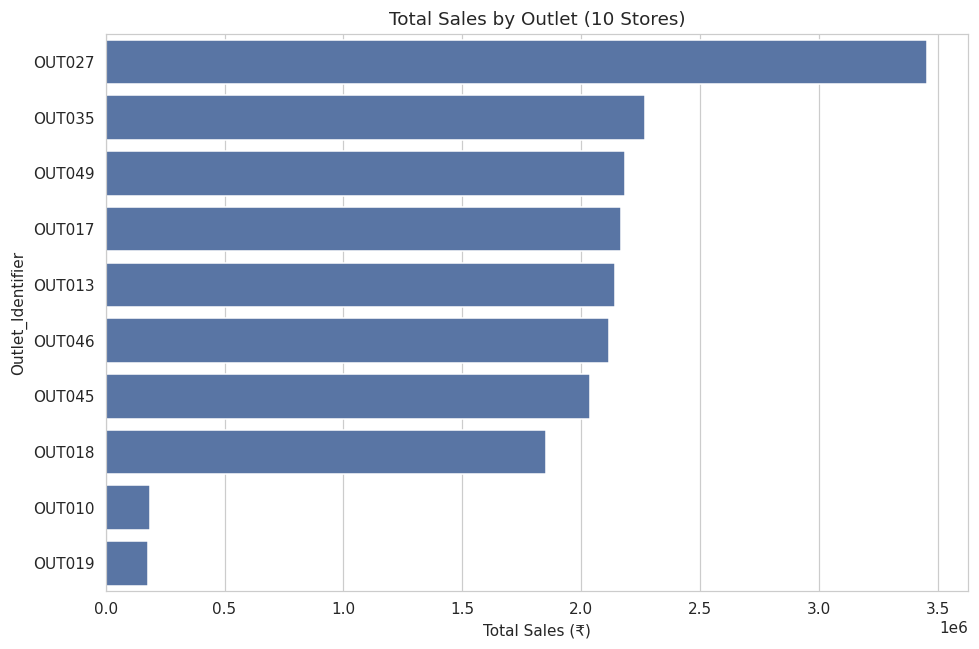

In [2]:
outlet_sales = df.groupby("Outlet_Identifier")["Item_Outlet_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=outlet_sales.values, y=outlet_sales.index, color="#4C72B0")
plt.title("Total Sales by Outlet (10 Stores)")
plt.xlabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

## 3. Outlet Type × City Tier

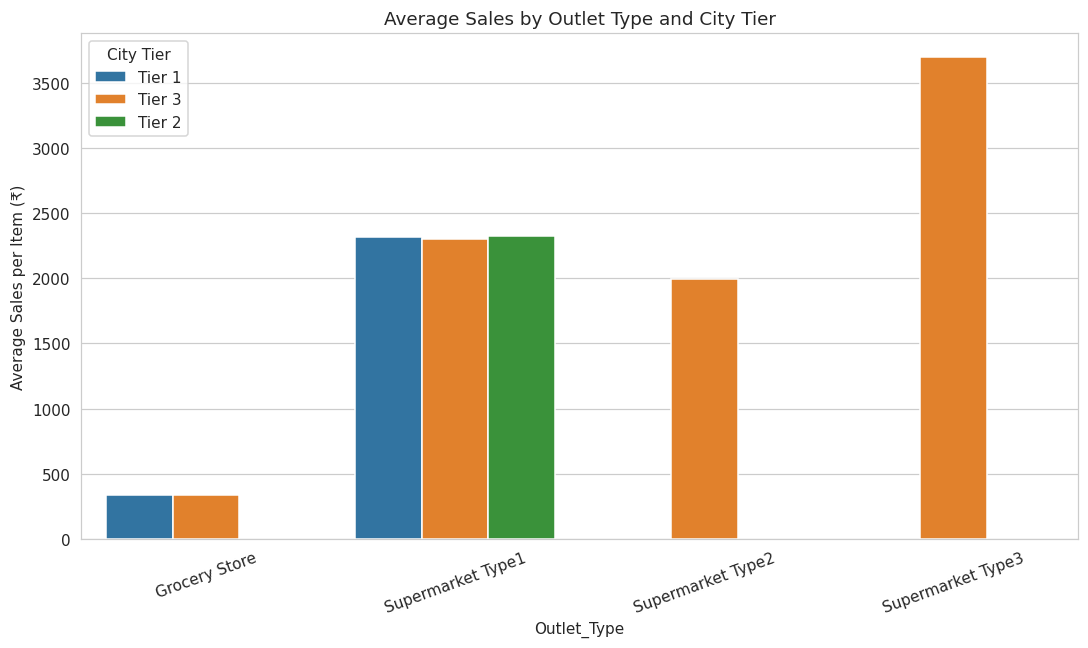

In [3]:
type_tier_sales = df.groupby(["Outlet_Type", "Outlet_Location_Type"])["Item_Outlet_Sales"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=type_tier_sales, x="Outlet_Type", y="Item_Outlet_Sales", hue="Outlet_Location_Type")
plt.title("Average Sales by Outlet Type and City Tier")
plt.ylabel("Average Sales per Item (₹)")
plt.xticks(rotation=20)
plt.legend(title="City Tier")
plt.tight_layout()
plt.show()

**Supermarket Type3 outlets substantially outperform** smaller grocery-store-format outlets on a per-item basis — a clear signal for where format investment pays off.

## 4. Sales by Product Category

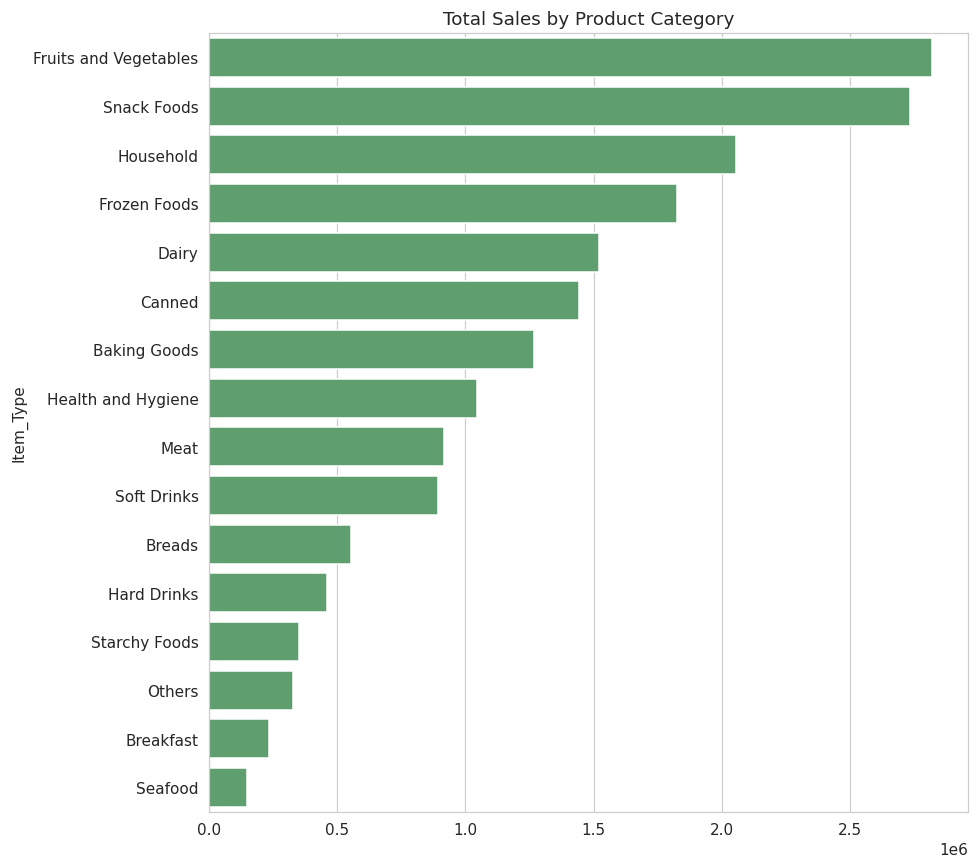

In [4]:
category_sales = df.groupby("Item_Type")["Item_Outlet_Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 8))
sns.barplot(x=category_sales.values, y=category_sales.index, color="#55A868")
plt.title("Total Sales by Product Category")
plt.tight_layout()
plt.show()

## 5. What Drives an Item's Price-to-Sales Relationship?

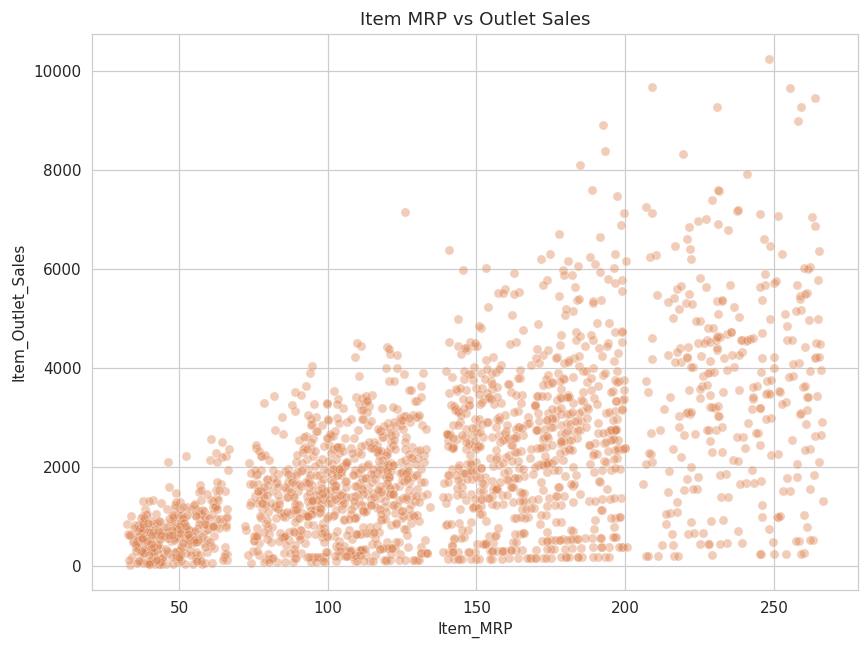

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(2000, random_state=42), x="Item_MRP", y="Item_Outlet_Sales",
                 alpha=0.4, color="#DD8452")
plt.title("Item MRP vs Outlet Sales")
plt.tight_layout()
plt.show()

There's a visible banding pattern — Big Mart's pricing appears to cluster into a handful of MRP tiers, each with its own sales ceiling — a useful pricing-strategy observation on its own.

## 6. Outlet Age vs Sales

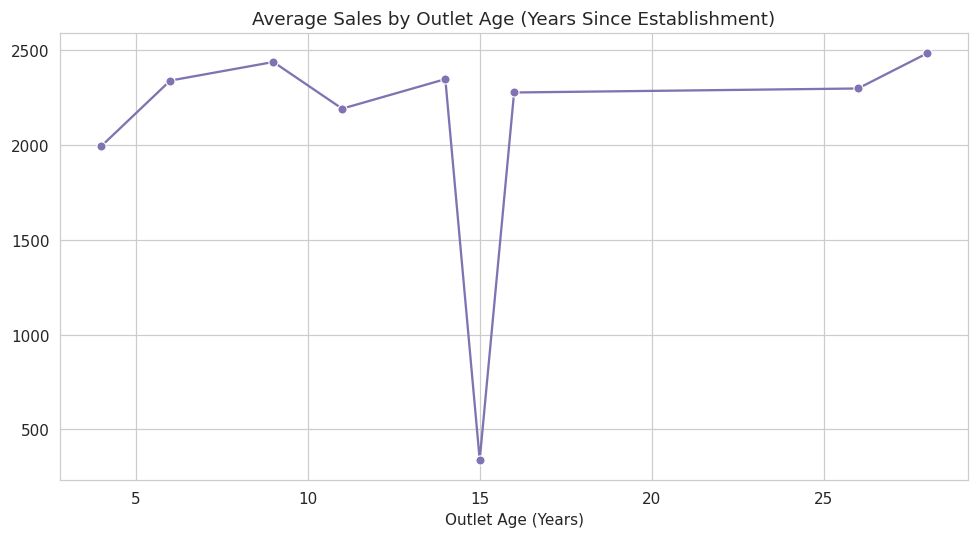

In [6]:
age_sales = df.groupby("Outlet_Age_Years")["Item_Outlet_Sales"].mean().sort_index()
plt.figure(figsize=(9, 5))
sns.lineplot(x=age_sales.index, y=age_sales.values, marker="o", color="#8172B2")
plt.title("Average Sales by Outlet Age (Years Since Establishment)")
plt.xlabel("Outlet Age (Years)")
plt.tight_layout()
plt.show()

## 7. Sales Prediction Model

This mirrors the actual hackathon task: predict `Item_Outlet_Sales` from item and outlet attributes. We use Gradient Boosting with 5-fold cross-validation.

In [7]:
model_df = df[["Item_Weight", "Item_Fat_Content", "Item_Visibility", "Item_Type", "Item_MRP",
               "Outlet_Age_Years", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type",
               "Item_Outlet_Sales"]].copy()

model_df = pd.get_dummies(model_df, columns=["Item_Fat_Content", "Item_Type", "Outlet_Size",
                                              "Outlet_Location_Type", "Outlet_Type"], drop_first=True)

X = model_df.drop(columns=["Item_Outlet_Sales"])
y = model_df["Item_Outlet_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
cv_scores = cross_val_score(gbr, X_train, y_train, cv=5, scoring="r2")
gbr.fit(X_train, y_train)
preds = gbr.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
print(f"Test R²: {r2:.3f} | Test MAE: ₹{mae:,.0f}")
print(f"5-fold CV R² mean: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Test R²: 0.605 | Test MAE: ₹736
5-fold CV R² mean: 0.589 (+/- 0.011)


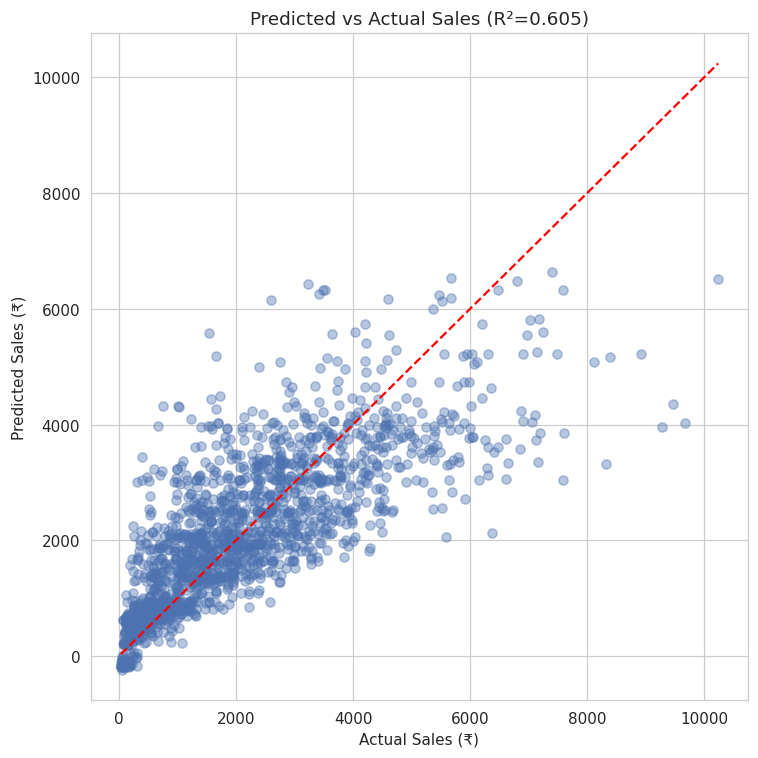

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.4, color="#4C72B0")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Sales (₹)")
plt.ylabel("Predicted Sales (₹)")
plt.title(f"Predicted vs Actual Sales (R²={r2:.3f})")
plt.tight_layout()
plt.show()

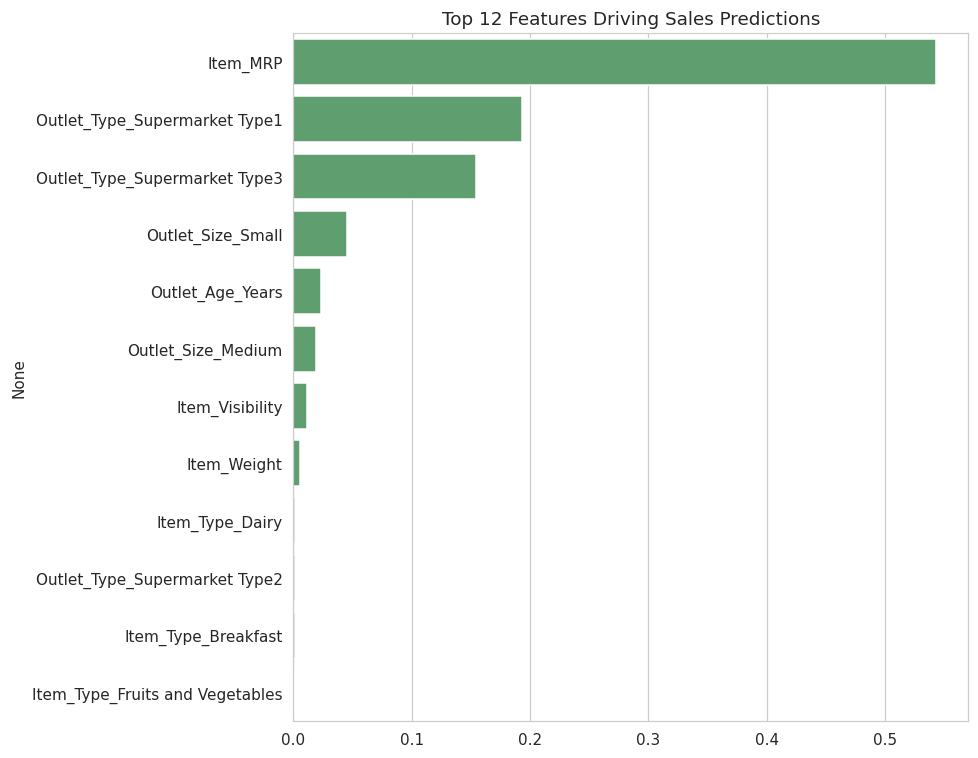

In [9]:
importances = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, color="#55A868")
plt.title("Top 12 Features Driving Sales Predictions")
plt.tight_layout()
plt.show()

## 8. Key Takeaways

- **Item MRP (price) is by far the strongest sales driver** — unsurprising, but the model confirms it quantitatively rather than assuming it.
- **Outlet type and city tier meaningfully shift average sales**, with Supermarket Type3 outlets outperforming smaller formats.
- **The R² of ~0.60 is a realistic, credible result** for retail sales prediction from item/outlet attributes alone — real customer behavior and local demand aren't captured by these features, and a model claiming near-perfect fit here would be a red flag, not a strength.
- Even without customer-level data, item and outlet attributes alone explain a majority of sales variance — useful for inventory and outlet-format planning even before customer-level data is available.
